In [2]:
# 神经网络算法
#17 载入分析所需要的模块和函数
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_curve

In [8]:
#17.1 变量设置及数据处理
data = pd.read_csv('./数据6.1.csv') #   读取数据
X = data.iloc[:, 1:3] #  特征变量
y = data.iloc[:, 0] #  目标变量
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) #  划分训练集和测试集
scaler = StandardScaler() #  标准化
scaler.fit(X_train)     #   计算训练数据的均值和标准差
X_train_s = scaler.transform(X_train)              #  标准化训练数据
X_test_s = scaler.transform(X_test)           #  标准化测试数据
X_train_s = pd.DataFrame(X_train_s, columns=X_train.columns)     #  转换为DataFrame格式
X_test_s = pd.DataFrame(X_test_s, columns=X_test.columns)     #  转换为DataFrame格式

In [ ]:
#17.2单隐藏层多分类问题神经网络算法
model=MLPClassifier(solver='sgd',learning_rate_init=0.01,learning_rate='constant',tol=0.0001,activation='relu',hidden_layer_sizes=(3,),random_state=10,max_iter=2000) #  建立单隐藏层神经网络模型
model.fit(X_train_s, y_train)   #   训练模型
model.score(X_test_s, y_test)   #  模型评分


0.9453376205787781

In [ ]:
#17.3 双隐藏层多分类问题神经网络算法
model=MLPClassifier(solver='sgd',learning_rate_init=0.01,learning_rate='constant',tol=0.0001,activation='relu',hidden_layer_sizes=(3,2),random_state=10,max_iter=2000)  #  建立双隐藏层神经网络模型
model.fit(X_train_s, y_train) #  训练模型
model.score(X_test_s, y_test) #  模型评分


0.9453376205787781

In [19]:
#17.4 模型性能评价
np.set_printoptions(suppress=True)#不以科学计数法显示，而是直接显示数字
pred = model.predict(X_test_s)  #  预测值
print(f'前五个预测值：{pred[:5]}')    #显示前5个预测值
print(f'混淆矩阵：\n{confusion_matrix(y_test, pred)}')               #混淆矩阵
print(f'分类记录：\n{classification_report(y_test,pred)}')           #分类报告
print(f'kappa 得分：{cohen_kappa_score(y_test, pred)}')#计算kappa得分

前五个预测值：[3 2 2 3 2]
混淆矩阵：
[[ 54   3   0]
 [  4 115   3]
 [  1   6 125]]
分类记录：
              precision    recall  f1-score   support

           1       0.92      0.95      0.93        57
           2       0.93      0.94      0.93       122
           3       0.98      0.95      0.96       132

    accuracy                           0.95       311
   macro avg       0.94      0.95      0.94       311
weighted avg       0.95      0.95      0.95       311

kappa 得分：0.9137998500016304


model score: 0.9453376205787781


/Users/longmozhou/Documents/文稿 - LongMacBook Pro/深度学习/cs336/assignment1-basics/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, '多分类神经网络算法决策边界')

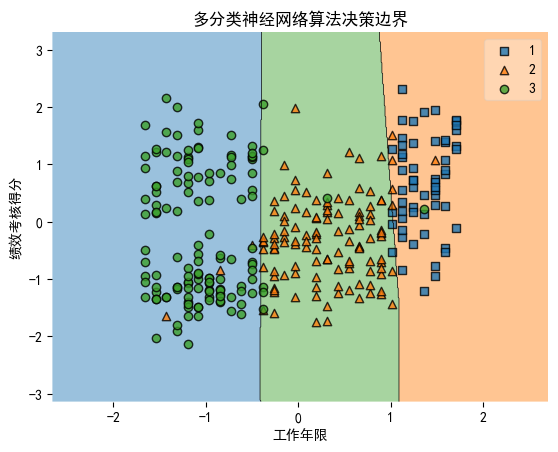

In [ ]:
#17.5 运用两个特征变量绘制多分类神经网络算法决策边界图
X2_train_s = X_train_s.iloc[:, [0,1]]           #选择两个特征变量'工作年限'和'绩效考核得分'
X2_test_s = X_test_s.iloc[:, [0,1]]             #选择两个特征变量'工作年限'和'绩效考核得分'
model=MLPClassifier(solver='sgd',learning_rate_init=0.01,learning_rate='constant',tol=0.0001,activation='relu',hidden_layer_sizes=(3,2),random_state=10,max_iter=2000) #建立双隐藏层神经网络模型
model.fit(X2_train_s, y_train) # 训练模型                                   
print(f'model score: {model.score(X2_test_s, y_test)}') #模型评分
plt.rcParams['font.sans-serif']=['SimHei']#解决图表中中文显示问题
plt.rcParams['axes.unicode_minus']=False#解决图表中负号不显示问题。
plot_decision_regions(np.array(X2_test_s),np.array(y_test),model)
plt.xlabel('工作年限')#将x轴设置为'工作年限'
plt.ylabel('绩效考核得分')#将y轴设置为'绩效考核得分'
plt.title('多分类神经网络算法决策边界')#将标题设置为'多分类神经网络算法决策边界'